In [ ]:
import json
from pathlib import Path

# 改成你的 trades.jsonl 路径
TRADES_PATH = Path("/vault/core/data/poly/tracker_0x8dxd/trades.jsonl")
TOP2_PATH = Path("eda/01_etl/output/top2.json")

# 要核对的两个市场（可从 top2.json 读）
CID_MAX_PROFIT = "0x4268e0943b2c8e28af78c01c7ebe1af5c401f3f9eaa059531fcda1c0a509b580"
CID_MAX_LOSS   = "0x149b6f404cd4cbc07515d49cac70126b2aa6e1a678b11da82dcb5792a138f971"

/tmp/ipykernel_1562352/256729727.py:219: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


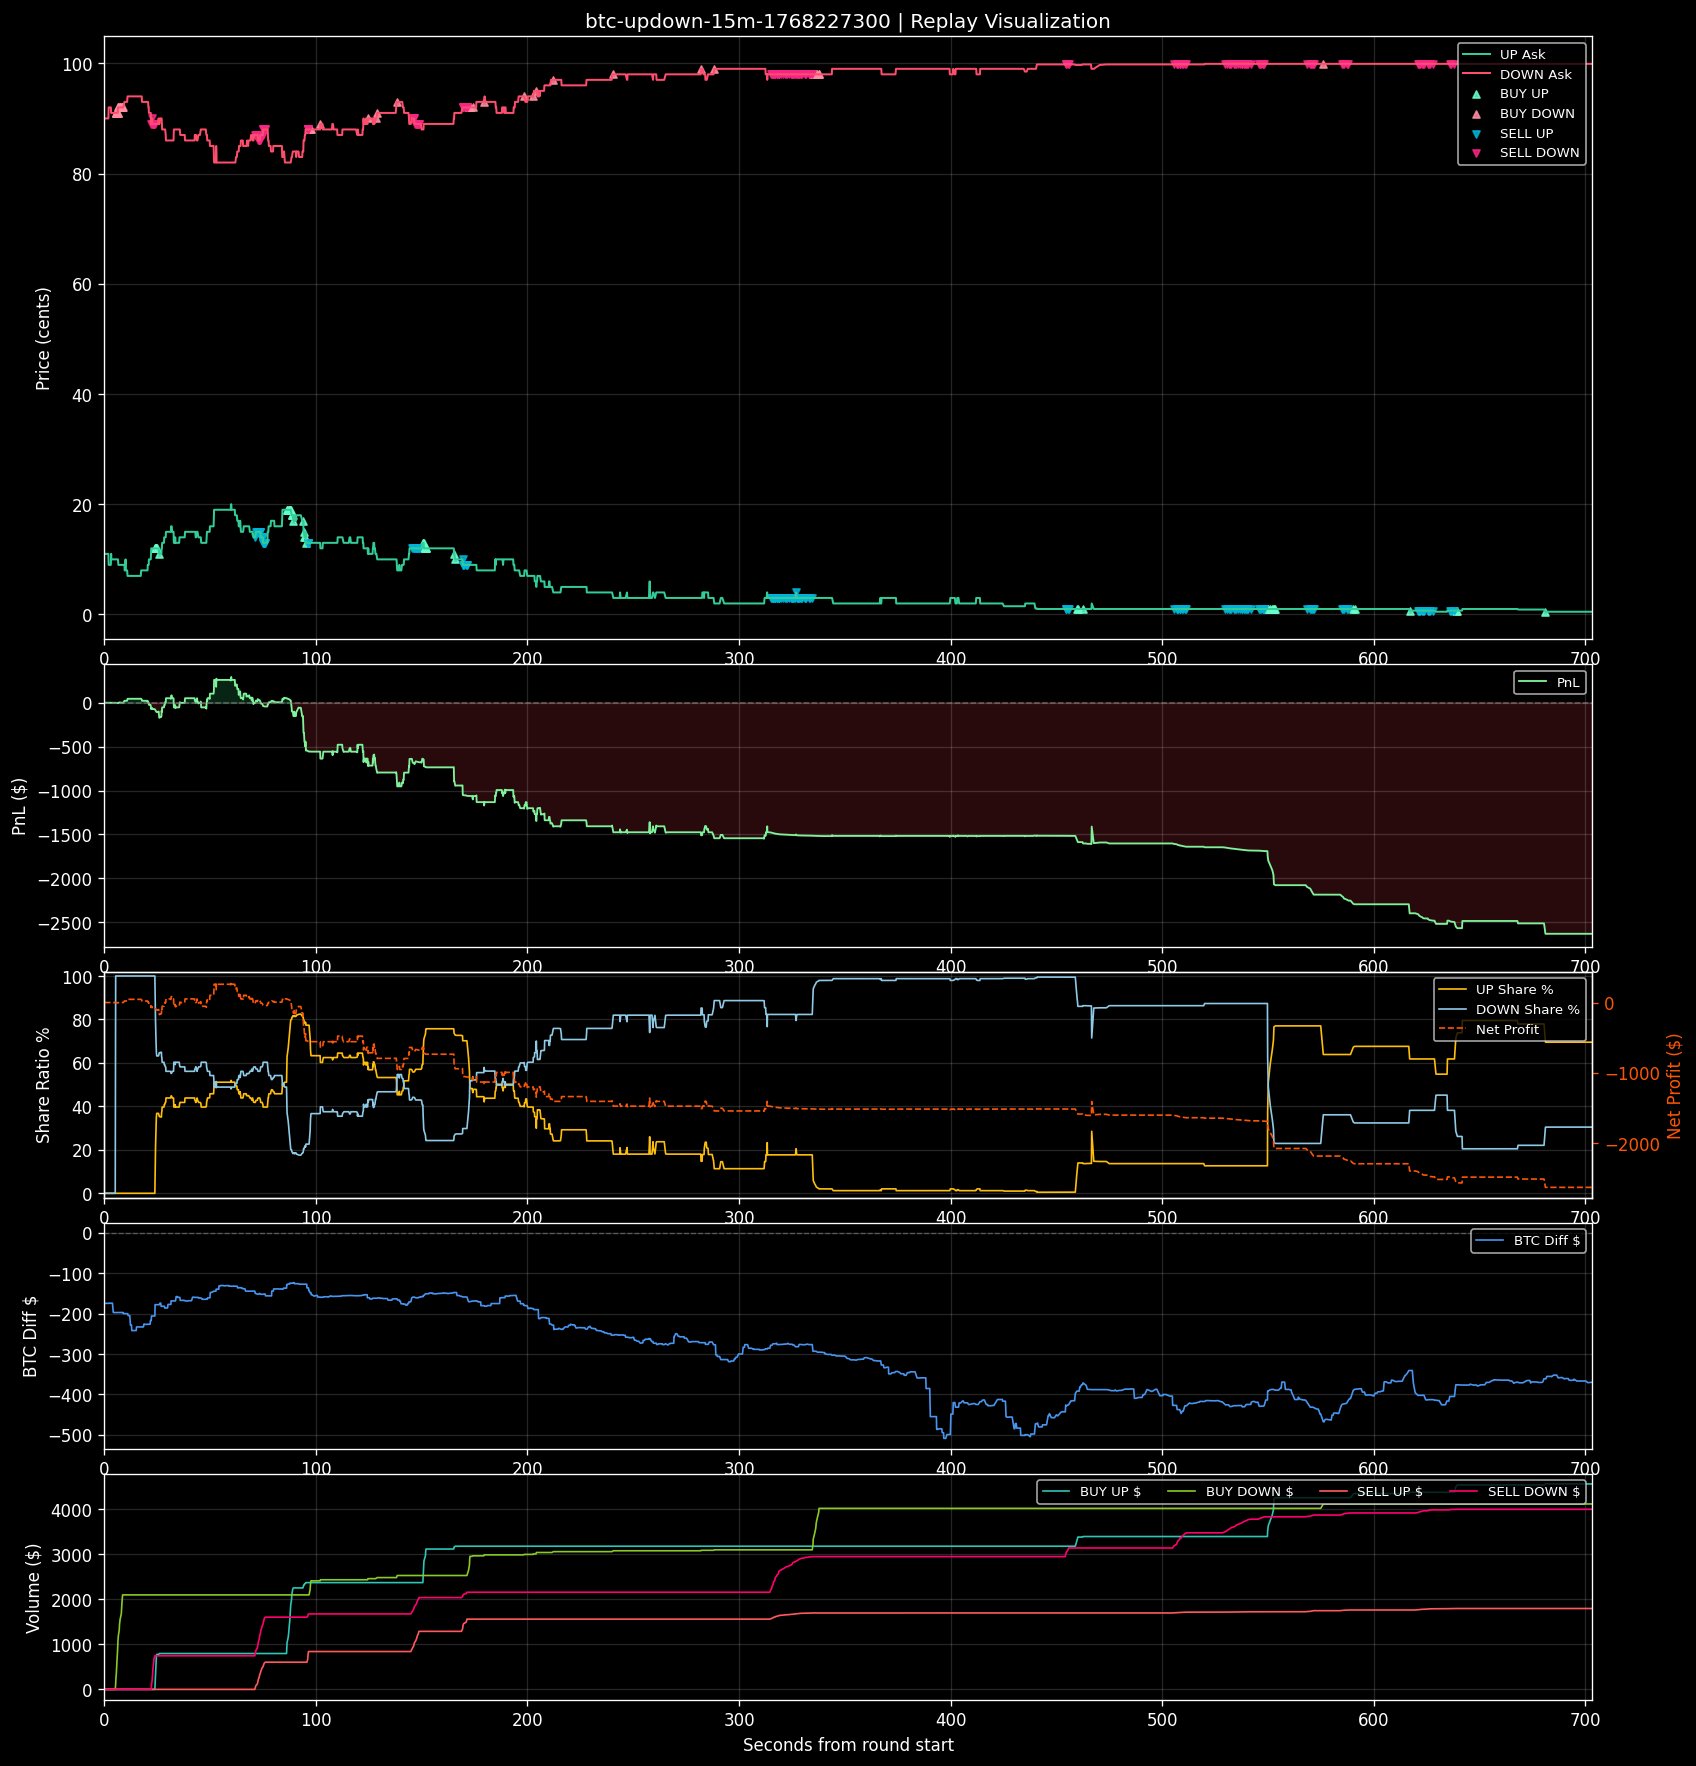

Round: btc-updown-15m-1768227300
Final net worth: 368.99
Final PnL: -2631.01
Buy UP / DOWN: 4565.98 / 4121.03
Sell UP / DOWN: 1797.75 / 4002.56


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# --------------------
# 1) 读取与预处理
# --------------------
csv_path = '/home/hliu/poly/2026-01-12.csv'
df = pd.read_csv(csv_path)

# 只保留一个 round（和截图一致地展示单局）
round_slug = df['roundSlug'].iloc[0]
r = df[df['roundSlug'] == round_slug].copy()

# 时间轴：从该 round 开始后的秒数
r['t_sec'] = (r['timestamp'] - r['timestamp'].iloc[0]) / 1000.0

# 价格转成 cents 方便和截图视觉一致（0~100）
r['up_c'] = r['upAsk'] * 100.0
r['down_c'] = r['downAsk'] * 100.0
r['up_mid'] = ((r['upAsk'] + r['upBid']) / 2.0) * 100.0
r['down_mid'] = ((r['downAsk'] + r['downBid']) / 2.0) * 100.0

# --------------------
# 2) 简单策略模拟（复线用）
# --------------------
# 目标：在 up/down 两边做仓位切换，并记录买卖成交额、PnL、仓位占比
capital = 3000.0
cash = capital
up_shares = 0.0
down_shares = 0.0

trade_records = []

# 信号：用 btcDiff 的滚动 zscore 做偏向判断
w = 240  # 大约 2~4 分钟量级（按采样密度）
mu = r['btcDiff'].rolling(w, min_periods=30).mean()
sd = r['btcDiff'].rolling(w, min_periods=30).std().replace(0, np.nan)
z = ((r['btcDiff'] - mu) / sd).fillna(0.0)
r['sig_z'] = z

buy_up_usd = 0.0
buy_down_usd = 0.0
sell_up_usd = 0.0
sell_down_usd = 0.0

buy_up_curve, buy_down_curve = [], []
sell_up_curve, sell_down_curve = [], []

pnl_curve = []
up_ratio_curve = []
down_ratio_curve = []
net_worth_curve = []

buy_up_pts_t, buy_up_pts_y = [], []
buy_down_pts_t, buy_down_pts_y = [], []
sell_up_pts_t, sell_up_pts_y = [], []
sell_down_pts_t, sell_down_pts_y = [], []

for i, row in r.iterrows():
    up_ask = row['upAsk']
    down_ask = row['downAsk']
    up_mid = row['up_mid'] / 100.0
    down_mid = row['down_mid'] / 100.0
    t = row['t_sec']
    sig = row['sig_z']

    # 组合净值（按 mid 估值）
    net_worth = cash + up_shares * up_mid + down_shares * down_mid

    # 风险预算：最多把净值的 70% 配到仓位
    max_gross = net_worth * 0.70
    gross_pos = up_shares * up_mid + down_shares * down_mid

    # 阈值策略（复线）：
    # sig > +0.8 偏多 BTC -> 更偏向 UP
    # sig < -0.8 偏空 BTC -> 更偏向 DOWN
    # 中间区域逐步减仓
    trade_usd = min(120.0, max(0.0, max_gross - gross_pos))

    if sig > 0.8 and trade_usd > 10 and cash > 10:
        spend = min(trade_usd, cash)
        qty = spend / up_ask
        up_shares += qty
        cash -= spend
        buy_up_usd += spend
        buy_up_pts_t.append(t)
        buy_up_pts_y.append(row['up_c'])

    elif sig < -0.8 and trade_usd > 10 and cash > 10:
        spend = min(trade_usd, cash)
        qty = spend / down_ask
        down_shares += qty
        cash -= spend
        buy_down_usd += spend
        buy_down_pts_t.append(t)
        buy_down_pts_y.append(row['down_c'])

    elif -0.25 < sig < 0.25:
        # 信号回归中性时，轻微止盈/减仓
        if up_shares > 5:
            qty = up_shares * 0.05
            recv = qty * (row['upBid'])
            up_shares -= qty
            cash += recv
            sell_up_usd += recv
            sell_up_pts_t.append(t)
            sell_up_pts_y.append(row['up_c'])

        if down_shares > 5:
            qty = down_shares * 0.05
            recv = qty * (row['downBid'])
            down_shares -= qty
            cash += recv
            sell_down_usd += recv
            sell_down_pts_t.append(t)
            sell_down_pts_y.append(row['down_c'])

    # 重新估值
    net_worth = cash + up_shares * up_mid + down_shares * down_mid
    pnl = net_worth - capital

    up_val = up_shares * up_mid
    down_val = down_shares * down_mid
    total_val = max(1e-9, up_val + down_val)

    pnl_curve.append(pnl)
    up_ratio_curve.append(100.0 * up_val / total_val)
    down_ratio_curve.append(100.0 * down_val / total_val)
    net_worth_curve.append(net_worth)

    buy_up_curve.append(buy_up_usd)
    buy_down_curve.append(buy_down_usd)
    sell_up_curve.append(sell_up_usd)
    sell_down_curve.append(sell_down_usd)

r['pnl'] = pnl_curve
r['up_ratio'] = up_ratio_curve
r['down_ratio'] = down_ratio_curve
r['net_worth'] = net_worth_curve
r['buy_up_usd'] = buy_up_curve
r['buy_down_usd'] = buy_down_curve
r['sell_up_usd'] = sell_up_curve
r['sell_down_usd'] = sell_down_curve

# --------------------
# 3) 绘图（多面板，暗色风格）
# --------------------
plt.style.use('dark_background')
fig = plt.figure(figsize=(16, 18), dpi=120)
gs = GridSpec(5, 1, height_ratios=[3.2, 1.5, 1.2, 1.2, 1.2], hspace=0.08)

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1], sharex=ax1)
ax3 = fig.add_subplot(gs[2], sharex=ax1)
ax4 = fig.add_subplot(gs[3], sharex=ax1)
ax5 = fig.add_subplot(gs[4], sharex=ax1)

# Panel 1: up/down 价格
ax1.plot(r['t_sec'], r['up_c'], color='#33cc99', lw=1.2, label='UP Ask')
ax1.plot(r['t_sec'], r['down_c'], color='#ff4d6d', lw=1.2, label='DOWN Ask')

ax1.scatter(buy_up_pts_t, buy_up_pts_y, marker='^', s=18, color='#66ffcc', label='BUY UP', alpha=0.85)
ax1.scatter(buy_down_pts_t, buy_down_pts_y, marker='^', s=18, color='#ff8fa3', label='BUY DOWN', alpha=0.85)
ax1.scatter(sell_up_pts_t, sell_up_pts_y, marker='v', s=18, color='#00b4d8', label='SELL UP', alpha=0.85)
ax1.scatter(sell_down_pts_t, sell_down_pts_y, marker='v', s=18, color='#f72585', label='SELL DOWN', alpha=0.85)

ax1.set_ylabel('Price (cents)')
ax1.grid(alpha=0.15)
ax1.legend(loc='upper right', ncol=1, fontsize=8)
ax1.set_title(f"{round_slug} | Replay Visualization")

# Panel 2: PnL
ax2.plot(r['t_sec'], r['pnl'], color='#7ef29a', lw=1.1, label='PnL')
ax2.axhline(0, color='gray', lw=0.9, ls='--', alpha=0.7)
ax2.fill_between(r['t_sec'], r['pnl'], 0, where=(r['pnl'] >= 0), color='#2ecc71', alpha=0.18)
ax2.fill_between(r['t_sec'], r['pnl'], 0, where=(r['pnl'] < 0), color='#e63946', alpha=0.18)
ax2.set_ylabel('PnL ($)')
ax2.grid(alpha=0.15)
ax2.legend(loc='upper right', fontsize=8)

# Panel 3: 仓位占比 + 净值
ax3.plot(r['t_sec'], r['up_ratio'], color='#ffbe0b', lw=1.0, label='UP Share %')
ax3.plot(r['t_sec'], r['down_ratio'], color='#8ecae6', lw=1.0, label='DOWN Share %')
ax3.set_ylabel('Share Ratio %')
ax3.set_ylim(-2, 102)
ax3.grid(alpha=0.15)

ax3r = ax3.twinx()
ax3r.plot(r['t_sec'], r['net_worth'] - capital, color='#fb5607', lw=1.0, ls='--', label='Net Profit')
ax3r.set_ylabel('Net Profit ($)', color='#fb5607')
ax3r.tick_params(axis='y', colors='#fb5607')

h1, l1 = ax3.get_legend_handles_labels()
h2, l2 = ax3r.get_legend_handles_labels()
ax3.legend(h1 + h2, l1 + l2, loc='upper right', fontsize=8)

# Panel 4: BTC diff
ax4.plot(r['t_sec'], r['btcDiff'], color='#4895ef', lw=1.0, label='BTC Diff $')
ax4.axhline(0, color='gray', lw=0.8, ls='--', alpha=0.6)
ax4.set_ylabel('BTC Diff $')
ax4.grid(alpha=0.15)
ax4.legend(loc='upper right', fontsize=8)

# Panel 5: 累计成交额曲线（可替代截图中柱状成交分布）
ax5.plot(r['t_sec'], r['buy_up_usd'], color='#2ec4b6', lw=1.0, label='BUY UP $')
ax5.plot(r['t_sec'], r['buy_down_usd'], color='#8ac926', lw=1.0, label='BUY DOWN $')
ax5.plot(r['t_sec'], r['sell_up_usd'], color='#ff595e', lw=1.0, label='SELL UP $')
ax5.plot(r['t_sec'], r['sell_down_usd'], color='#ff006e', lw=1.0, label='SELL DOWN $')
ax5.set_ylabel('Volume ($)')
ax5.set_xlabel('Seconds from round start')
ax5.grid(alpha=0.15)
ax5.legend(loc='upper right', ncol=4, fontsize=8)

for ax in [ax1, ax2, ax3, ax4, ax5]:
    ax.margins(x=0)

plt.tight_layout()
plt.show()

print('Round:', round_slug)
print('Final net worth:', round(r['net_worth'].iloc[-1], 2))
print('Final PnL:', round(r['pnl'].iloc[-1], 2))
print('Buy UP / DOWN:', round(r['buy_up_usd'].iloc[-1], 2), '/', round(r['buy_down_usd'].iloc[-1], 2))
print('Sell UP / DOWN:', round(r['sell_up_usd'].iloc[-1], 2), '/', round(r['sell_down_usd'].iloc[-1], 2))

In [3]:
import pandas as pd
path='/home/hliu/poly/2026-01-12.csv'
df=pd.read_csv(path,nrows=5)
print('columns:', list(df.columns))
print(df.head().to_string())

columns: ['timestamp', 'offsetMs', 'priceToBeat', 'btcPrice', 'btcDiff', 'btcDiffPct', 'upAsk', 'downAsk', 'upBid', 'downBid', 'sumAsk', 'roundSlug', 'secondsLeft']
       timestamp  offsetMs  priceToBeat  btcPrice  btcDiff  btcDiffPct  upAsk  downAsk  upBid  downBid  sumAsk                  roundSlug  secondsLeft
0  1768227477365    177365     90529.09  90354.76  -174.32     -0.0019   0.11      0.9    0.1     0.89    1.01  btc-updown-15m-1768227300          723
1  1768227477536    177536     90529.09  90354.76  -174.32     -0.0019   0.11      0.9    0.1     0.89    1.01  btc-updown-15m-1768227300          722
2  1768227477670    177670     90529.09  90354.76  -174.32     -0.0019   0.11      0.9    0.1     0.89    1.01  btc-updown-15m-1768227300          722
3  1768227477826    177826     90529.09  90354.76  -174.32     -0.0019   0.11      0.9    0.1     0.89    1.01  btc-updown-15m-1768227300          722
4  1768227477930    177930     90529.09  90354.76  -174.32     -0.0019   0.11   

In [3]:
def pnl_for_condition_id(path: Path, condition_id: str) -> dict:
    cost = revenue = 0.0
    n_buys = n_sells = 0
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                r = json.loads(line)
            except json.JSONDecodeError:
                continue
            if (r.get("conditionId") or r.get("condition_id")) != condition_id:
                continue
            try:
                price = float(r.get("price") or r.get("limitPrice") or 0)
                size  = float(r.get("size") or r.get("amount") or 0)
            except (TypeError, ValueError):
                continue
            side = (r.get("side") or "").upper()
            notional = price * size
            rows.append({"side": side, "price": price, "size": size, "notional": notional})
            if side == "BUY":
                cost += notional
                n_buys += 1
            elif side == "SELL":
                revenue += notional
                n_sells += 1
    return {
        "conditionId": condition_id,
        "cost": cost,
        "revenue": revenue,
        "pnl": revenue - cost,
        "n_buys": n_buys,
        "n_sells": n_sells,
        "n_trades": len(rows),
    }

result_max = pnl_for_condition_id(TRADES_PATH, CID_MAX_PROFIT)
result_min = pnl_for_condition_id(TRADES_PATH, CID_MAX_LOSS)
print("最大盈利市场:", result_max)
print()
print("最大亏损市场:", result_min)

最大盈利市场: {'conditionId': '0x4268e0943b2c8e28af78c01c7ebe1af5c401f3f9eaa059531fcda1c0a509b580', 'cost': 1891.309196, 'revenue': 11003.110260000001, 'pnl': 9111.801064000001, 'n_buys': 9, 'n_sells': 3, 'n_trades': 12}

最大亏损市场: {'conditionId': '0x149b6f404cd4cbc07515d49cac70126b2aa6e1a678b11da82dcb5792a138f971', 'cost': 42546.97764600001, 'revenue': 419.10355999999996, 'pnl': -42127.874086, 'n_buys': 9, 'n_sells': 6, 'n_trades': 15}


In [4]:
def load_trades_by_condition(path: Path, condition_id: str) -> list[dict]:
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                r = json.loads(line)
            except json.JSONDecodeError:
                continue
            if (r.get("conditionId") or r.get("condition_id")) != condition_id:
                continue
            rows.append(r)
    return rows

trades_profit = load_trades_by_condition(TRADES_PATH, CID_MAX_PROFIT)
trades_loss   = load_trades_by_condition(TRADES_PATH, CID_MAX_LOSS)
print(f"最大盈利市场: {len(trades_profit)} 笔")
print(f"最大亏损市场: {len(trades_loss)} 笔")

最大盈利市场: 12 笔
最大亏损市场: 15 笔


In [5]:
import pandas as pd

# 挑要看的列，按需增删
COLS = [
    "timestamp", "local_receipt_ts_ms", "side", "price", "size",
    "title", "slug", "outcome", "outcomeIndex",
    "transactionHash", "conditionId", "asset"
]

def to_df(trades: list[dict], columns: list[str]) -> pd.DataFrame:
    df = pd.DataFrame(trades)
    # 只保留存在的列
    exist = [c for c in columns if c in df.columns]
    df = df[exist] if exist else df
    # 方便看金额
    if "price" in df.columns and "size" in df.columns:
        df["notional"] = pd.to_numeric(df["price"], errors="coerce") * pd.to_numeric(df["size"], errors="coerce")
    if "timestamp" in df.columns:
        df["time_utc"] = pd.to_datetime(df["timestamp"], unit="s", utc=True)
    return df

df_profit = to_df(trades_profit, COLS)
df_loss   = to_df(trades_loss, COLS)

In [6]:
# 最大盈利市场明细
display(df_profit)

# 最大亏损市场明细
display(df_loss)

,timestamp,local_receipt_ts_ms,side,price,size,title,slug,outcome,outcomeIndex,transactionHash,conditionId,asset,notional,time_utc
0,1770805647,1770805695105,BUY,0.610000,27.400000,LoL: Team WE vs LNG Esports - Game 3 Winner,lol-we-lng-2026-02-11-game3,LNG Esports,1,0x54b83f9fa298aa55f89e89712f14be4fd498d5f23011...,0x4268e0943b2c8e28af78c01c7ebe1af5c401f3f9eaa0...,9659372897559588945483443531584199654679106577...,16.714000,2026-02-11 10:27:27+00:00
1,1770807723,1770807806737,BUY,0.420000,23.809522,LoL: Team WE vs LNG Esports - Game 3 Winner,lol-we-lng-2026-02-11-game3,Team WE,0,0x80c8c0a2e99f5eb67ba9d0b004dc4fcd1e21d4a5c930...,0x4268e0943b2c8e28af78c01c7ebe1af5c401f3f9eaa0...,5445764102801431684005304820798827622541040730...,9.999999,2026-02-11 11:02:03+00:00
2,1770808623,1770808712772,BUY,0.600000,16.666665,LoL: Team WE vs LNG Esports - Game 3 Winner,lol-we-lng-2026-02-11-game3,LNG Esports,1,0x870ec5ae13cc4bb67468eced3577afcd87414453aa02...,0x4268e0943b2c8e28af78c01c7ebe1af5c401f3f9eaa0...,9659372897559588945483443531584199654679106577...,9.999999,2026-02-11 11:17:03+00:00
3,1770808623,1770808712772,BUY,0.600000,45.000000,LoL: Team WE vs LNG Esports - Game 3 Winner,lol-we-lng-2026-02-11-game3,LNG Esports,1,0x3847f5448bf1ea8e17826ccd764a2812c51b4c659f6b...,0x4268e0943b2c8e28af78c01c7ebe1af5c401f3f9eaa0...,9659372897559588945483443531584199654679106577...,27.000000,2026-02-11 11:17:03+00:00
4,1770808985,1770809014779,BUY,0.750000,1.960000,LoL: Team WE vs LNG Esports - Game 3 Winner,lol-we-lng-2026-02-11-game3,LNG Esports,1,0xa986f0a7590f0597ffa235abbd55e6a6be2000b641dd...,0x4268e0943b2c8e28af78c01c7ebe1af5c401f3f9eaa0...,9659372897559588945483443531584199654679106577...,1.470000,2026-02-11 11:23:05+00:00
5,1770808985,1770809014779,BUY,0.740000,1.986485,LoL: Team WE vs LNG Esports - Game 3 Winner,lol-we-lng-2026-02-11-game3,LNG Esports,1,0xa1843b6aba28ac39b265a4eb58d460c811f45ac1902d...,0x4268e0943b2c8e28af78c01c7ebe1af5c401f3f9eaa0...,9659372897559588945483443531584199654679106577...,1.469998,2026-02-11 11:23:05+00:00
6,1770809255,1770809316593,SELL,0.290000,387.120000,LoL: Team WE vs LNG Esports - Game 3 Winner,lol-we-lng-2026-02-11-game3,Team WE,0,0x4f6d0c1020357fa8c6a4a2694bd4a668b4f193314eed...,0x4268e0943b2c8e28af78c01c7ebe1af5c401f3f9eaa0...,5445764102801431684005304820798827622541040730...,112.264800,2026-02-11 11:27:35+00:00
7,1770809251,1770809316593,BUY,0.300000,100.000000,LoL: Team WE vs LNG Esports - Game 3 Winner,lol-we-lng-2026-02-11-game3,Team WE,0,0xcbd8a2f39e6fa4deef61f7598a9c71e20efd4e3bdfb2...,0x4268e0943b2c8e28af78c01c7ebe1af5c401f3f9eaa0...,5445764102801431684005304820798827622541040730...,30.000000,2026-02-11 11:27:31+00:00
8,1770809249,1770809316593,BUY,0.700000,2355.000000,LoL: Team WE vs LNG Esports - Game 3 Winner,lol-we-lng-2026-02-11-game3,LNG Esports,1,0x790bff2e6013357c6fa78b8f6f0c321674daafa2ac72...,0x4268e0943b2c8e28af78c01c7ebe1af5c401f3f9eaa0...,9659372897559588945483443531584199654679106577...,1648.500000,2026-02-11 11:27:29+00:00
9,1770809883,1770809920626,BUY,0.755949,193.340000,LoL: Team WE vs LNG Esports - Game 3 Winner,lol-we-lng-2026-02-11-game3,LNG Esports,1,0x9bc858fd7ee8f18c8a7645458f37ac5b42464e7457ec...,0x4268e0943b2c8e28af78c01c7ebe1af5c401f3f9eaa0...,9659372897559588945483443531584199654679106577...,146.155200,2026-02-11 11:38:03+00:00


,timestamp,local_receipt_ts_ms,side,price,size,title,slug,outcome,outcomeIndex,transactionHash,conditionId,asset,notional,time_utc
0,1770794199,1770794232701,BUY,0.390000,9.440000,LoL: Invictus Gaming vs Oh My God - Game 2 Winner,lol-ig1-omg-2026-02-11-game2,Oh My God,1,0x633c154fafd63007fc993b8bbedf64ecbbd0028877b4...,0x149b6f404cd4cbc07515d49cac70126b2aa6e1a678b1...,1016727409981443172348259916075098346878811097...,3.681600,2026-02-11 07:16:39+00:00
1,1770794469,1770794534414,BUY,0.450000,5555.555554,LoL: Invictus Gaming vs Oh My God - Game 2 Winner,lol-ig1-omg-2026-02-11-game2,Oh My God,1,0xfdf39417d28fbe4e63d1c5db11117af4c4a662f5e131...,0x149b6f404cd4cbc07515d49cac70126b2aa6e1a678b1...,1016727409981443172348259916075098346878811097...,2499.999999,2026-02-11 07:21:09+00:00
2,1770794469,1770794534414,BUY,0.450000,200.000000,LoL: Invictus Gaming vs Oh My God - Game 2 Winner,lol-ig1-omg-2026-02-11-game2,Oh My God,1,0x6e97fe8743fc362bb5b77f31b3003fedf733ea41e59a...,0x149b6f404cd4cbc07515d49cac70126b2aa6e1a678b1...,1016727409981443172348259916075098346878811097...,90.000000,2026-02-11 07:21:09+00:00
3,1770795373,1770795439367,BUY,0.290000,161.260000,LoL: Invictus Gaming vs Oh My God - Game 2 Winner,lol-ig1-omg-2026-02-11-game2,Oh My God,1,0x46fe8365c5e5da8c608db823ca9998c9eb2fed391f08...,0x149b6f404cd4cbc07515d49cac70126b2aa6e1a678b1...,1016727409981443172348259916075098346878811097...,46.765400,2026-02-11 07:36:13+00:00
4,1770795373,1770795439367,BUY,0.290000,3.793102,LoL: Invictus Gaming vs Oh My God - Game 2 Winner,lol-ig1-omg-2026-02-11-game2,Oh My God,1,0x0c0f19e350d1abc5e452c2f65e520917528e4206580e...,0x149b6f404cd4cbc07515d49cac70126b2aa6e1a678b1...,1016727409981443172348259916075098346878811097...,1.099999,2026-02-11 07:36:13+00:00
5,1770795373,1770795439367,BUY,0.720000,2.777776,LoL: Invictus Gaming vs Oh My God - Game 2 Winner,lol-ig1-omg-2026-02-11-game2,Invictus Gaming,0,0x9c84cd150290391f7aeb58121b9e406795e4fdce2758...,0x149b6f404cd4cbc07515d49cac70126b2aa6e1a678b1...,8773979793955800326930698408645911776156224482...,1.999998,2026-02-11 07:36:13+00:00
6,1770795729,1770795740748,BUY,0.840000,200.000000,LoL: Invictus Gaming vs Oh My God - Game 2 Winner,lol-ig1-omg-2026-02-11-game2,Invictus Gaming,0,0xe8b8bd882bd0d0bc9079013a312b54de3b3b6aa19b97...,0x149b6f404cd4cbc07515d49cac70126b2aa6e1a678b1...,8773979793955800326930698408645911776156224482...,168.000000,2026-02-11 07:42:09+00:00
7,1770796005,1770796042190,SELL,0.980000,1.770000,LoL: Invictus Gaming vs Oh My God - Game 2 Winner,lol-ig1-omg-2026-02-11-game2,Invictus Gaming,0,0xd52b388818b2b2335a136824e9a569c01ccd55666f9e...,0x149b6f404cd4cbc07515d49cac70126b2aa6e1a678b1...,8773979793955800326930698408645911776156224482...,1.734600,2026-02-11 07:46:45+00:00
8,1770796003,1770796042190,BUY,0.990000,5.000000,LoL: Invictus Gaming vs Oh My God - Game 2 Winner,lol-ig1-omg-2026-02-11-game2,Invictus Gaming,0,0x7650ed244d4eed30cd9b8c6b3ddac8df8f3b29d9b8d4...,0x149b6f404cd4cbc07515d49cac70126b2aa6e1a678b1...,8773979793955800326930698408645911776156224482...,4.950000,2026-02-11 07:46:43+00:00
9,1770796003,1770796042190,SELL,0.010000,743.930000,LoL: Invictus Gaming vs Oh My God - Game 2 Winner,lol-ig1-omg-2026-02-11-game2,Oh My God,1,0xb028ec2468f2af191d2b224985a61408b0ef8b080789...,0x149b6f404cd4cbc07515d49cac70126b2aa6e1a678b1...,1016727409981443172348259916075098346878811097...,7.439300,2026-02-11 07:46:43+00:00
